# Deep Learning Lab: Recurrent Neural Networks (LSTMs)

## Learning Objectives
By the end of this lab, you will be able to:
1. Understand the architecture and components of RNNs and LSTMs
2. Implement LSTM networks using PyTorch
3. Apply LSTMs to sequence prediction tasks
4. Visualize and interpret LSTM behavior

## Table of Contents
1. Introduction to RNNs
2. The Vanishing Gradient Problem
3. LSTM Architecture
4. Part 1: Character-Level Language Model
5. Part 2: Time Series Prediction
6. Part 3: Sentiment Analysis
7. Visualizations and Analysis

## Setup and Imports

In [26]:
# Install any additional packages if needed
!pip install -q torchtext


[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Using device: cpu


## 1. Introduction to Recurrent Neural Networks

### Why RNNs?
Traditional neural networks assume inputs are independent. However, many real-world problems involve **sequential data** where order matters:
- Text and language
- Time series (stock prices, weather)
- Audio and speech
- Video frames

### RNN Architecture

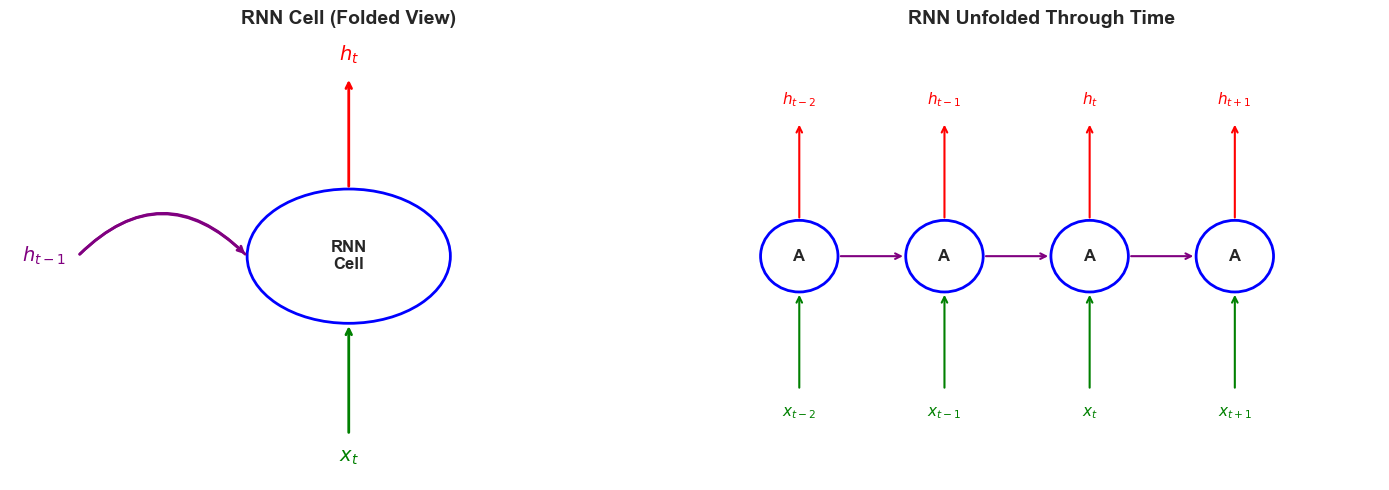

In [32]:
def visualize_rnn_architecture():
    """Visualize the basic RNN architecture"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Folded view
    ax1 = axes[0]
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)

    # Draw RNN cell
    circle = plt.Circle((5, 5), 1.5, fill=False, color='blue', linewidth=2)
    ax1.add_patch(circle)
    ax1.text(5, 5, 'RNN\nCell', ha='center', va='center', fontsize=12, fontweight='bold')

    # Input arrow
    ax1.annotate('', xy=(5, 3.5), xytext=(5, 1),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax1.text(5, 0.5, '$x_t$', ha='center', va='center', fontsize=14, color='green')

    # Output arrow
    ax1.annotate('', xy=(5, 9), xytext=(5, 6.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax1.text(5, 9.5, '$h_t$', ha='center', va='center', fontsize=14, color='red')

    # Recurrent connection
    ax1.annotate('', xy=(3.5, 5), xytext=(1, 5),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2,
                              connectionstyle='arc3,rad=-0.5'))
    ax1.annotate('', xy=(1, 5), xytext=(3.5, 5),
                arrowprops=dict(arrowstyle='-', color='purple', lw=2,
                              connectionstyle='arc3,rad=0.5'))
    ax1.text(0.5, 5, '$h_{t-1}$', ha='center', va='center', fontsize=14, color='purple')

    ax1.set_title('RNN Cell (Folded View)', fontsize=14, fontweight='bold')
    ax1.axis('off')

    # Unfolded view
    ax2 = axes[1]
    ax2.set_xlim(0, 14)
    ax2.set_ylim(0, 10)

    positions = [2, 5, 8, 11]
    labels = ['t-2', 't-1', 't', 't+1']

    for i, (pos, label) in enumerate(zip(positions, labels)):
        # Draw cell
        circle = plt.Circle((pos, 5), 0.8, fill=False, color='blue', linewidth=2)
        ax2.add_patch(circle)
        ax2.text(pos, 5, 'A', ha='center', va='center', fontsize=12, fontweight='bold')

        # Input
        ax2.annotate('', xy=(pos, 4.2), xytext=(pos, 2),
                    arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
        ax2.text(pos, 1.5, f'$x_{{{label}}}$', ha='center', va='center', fontsize=11, color='green')

        # Output
        ax2.annotate('', xy=(pos, 8), xytext=(pos, 5.8),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
        ax2.text(pos, 8.5, f'$h_{{{label}}}$', ha='center', va='center', fontsize=11, color='red')

        # Horizontal connection
        if i < len(positions) - 1:
            ax2.annotate('', xy=(positions[i+1]-0.8, 5), xytext=(pos+0.8, 5),
                        arrowprops=dict(arrowstyle='->', color='purple', lw=1.5))

    ax2.set_title('RNN Unfolded Through Time', fontsize=14, fontweight='bold')
    ax2.axis('off')

    plt.tight_layout()
    plt.savefig('rnn_architecture.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_rnn_architecture()

### RNN Equations

The basic RNN computes:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$
$$y_t = W_{hy} h_t + b_y$$

Where:
- $x_t$ is the input at time $t$
- $h_t$ is the hidden state at time $t$
- $y_t$ is the output at time $t$
- $W_{hh}, W_{xh}, W_{hy}$ are weight matrices
- $b_h, b_y$ are bias vectors

In [29]:
class SimpleRNN(nn.Module):
    """
    A simple RNN implementation from scratch to understand the mechanics
    """
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size

        # Weight matrices
        self.W_xh = nn.Linear(input_size, hidden_size, bias=False)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=True)
        self.W_hy = nn.Linear(hidden_size, output_size, bias=True)

    def forward(self, x, hidden=None):
        """
        x: (batch_size, seq_len, input_size)
        """
        batch_size, seq_len, _ = x.size()

        if hidden is None:
            hidden = torch.zeros(batch_size, self.hidden_size, device=x.device)

        outputs = []
        hiddens = [hidden]

        for t in range(seq_len):
            # Get input at time t
            x_t = x[:, t, :]

            # Compute new hidden state
            hidden = torch.tanh(self.W_xh(x_t) + self.W_hh(hidden))
            hiddens.append(hidden)

            # Compute output
            output = self.W_hy(hidden)
            outputs.append(output)

        outputs = torch.stack(outputs, dim=1)
        hiddens = torch.stack(hiddens[1:], dim=1)

        return outputs, hiddens

# Test the simple RNN
simple_rnn = SimpleRNN(input_size=10, hidden_size=20, output_size=5)
test_input = torch.randn(2, 15, 10)  # batch=2, seq_len=15, input_size=10
output, hidden_states = simple_rnn(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Hidden states shape: {hidden_states.shape}")

Input shape: torch.Size([2, 15, 10])
Output shape: torch.Size([2, 15, 5])
Hidden states shape: torch.Size([2, 15, 20])


## 2. The Vanishing Gradient Problem

RNNs suffer from the **vanishing gradient problem** during backpropagation through time (BPTT).

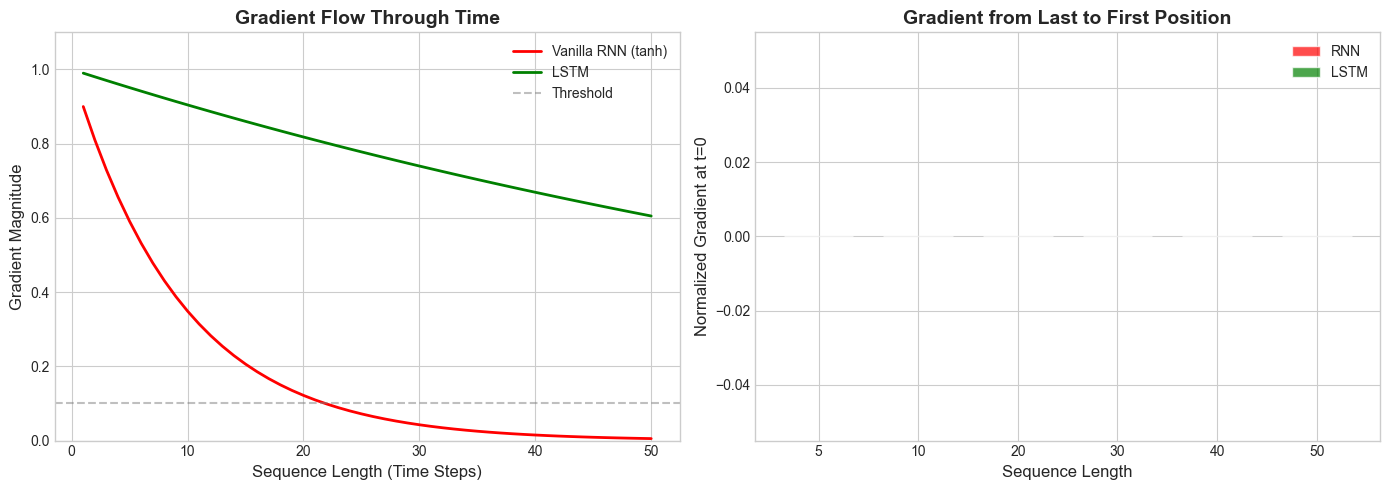

In [30]:

def visualize_vanishing_gradient():
    """Demonstrate the vanishing gradient problem"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Simulate gradient flow
    seq_lengths = range(1, 51)

    # RNN with tanh (gradients vanish)
    tanh_gradients = [0.9 ** t for t in seq_lengths]

    # LSTM (gradients preserved better)
    lstm_gradients = [0.99 ** t for t in seq_lengths]

    ax1 = axes[0]
    ax1.plot(seq_lengths, tanh_gradients, 'r-', linewidth=2, label='Vanilla RNN (tanh)')
    ax1.plot(seq_lengths, lstm_gradients, 'g-', linewidth=2, label='LSTM')
    ax1.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='Threshold')
    ax1.set_xlabel('Sequence Length (Time Steps)', fontsize=12)
    ax1.set_ylabel('Gradient Magnitude', fontsize=12)
    ax1.set_title('Gradient Flow Through Time', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.set_ylim(0, 1.1)

    # Show actual gradient computation
    ax2 = axes[1]

    # Compute real gradients for different sequence lengths
    def compute_gradient_norm(model_class, seq_len, hidden_size=32):
        model = model_class(10, hidden_size)
        x = torch.randn(1, seq_len, 10, requires_grad=True)

        if model_class == nn.RNN:
            output, _ = model(x)
        else:
            output, _ = model(x)

        loss = output[:, -1, :].sum()
        loss.backward()

        return x.grad[:, 0, :].norm().item()

    seq_lens = [5, 10, 20, 30, 40, 50]
    rnn_grads = []
    lstm_grads = []

    for sl in seq_lens:
        try:
            rnn_grads.append(compute_gradient_norm(nn.RNN, sl))
        except:
            rnn_grads.append(0)
        try:
            lstm_grads.append(compute_gradient_norm(nn.LSTM, sl))
        except:
            lstm_grads.append(0)

    # Normalize
    rnn_grads = np.array(rnn_grads) / (max(rnn_grads) + 1e-8)
    lstm_grads = np.array(lstm_grads) / (max(lstm_grads) + 1e-8)

    x_pos = np.arange(len(seq_lens))
    width = 0.35

    ax2.bar(x_pos - width/2, rnn_grads, width, label='RNN', color='red', alpha=0.7)
    ax2.bar(x_pos + width/2, lstm_grads, width, label='LSTM', color='green', alpha=0.7)
    ax2.set_xlabel('Sequence Length', fontsize=12)
    ax2.set_ylabel('Normalized Gradient at t=0', fontsize=12)
    ax2.set_title('Gradient from Last to First Position', fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(seq_lens)
    ax2.legend()

    plt.tight_layout()
    plt.savefig('vanishing_gradient.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_vanishing_gradient()

In [31]:
## 3. LSTM Architecture
LSTMs solve the vanishing gradient problem using **gates** and a **cell state**.

### LSTM Gates:
1. **Forget Gate ($f_t$)**: Decides what to forget from the cell state
2. **Input Gate ($i_t$)**: Decides what new information to store
3. **Output Gate ($o_t$)**: Decides what to output based on cell state

SyntaxError: invalid syntax (1476540664.py, line 2)

In [ ]:

def visualize_lstm_cell():
    """Create a detailed visualization of an LSTM cell"""
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 14)

    # Colors
    forget_color = '#FF6B6B'
    input_color = '#4ECDC4'
    output_color = '#45B7D1'
    cell_color = '#96CEB4'

    # Main cell body
    cell_rect = plt.Rectangle((4, 3), 12, 8, fill=True, facecolor='#F8F9FA',
                               edgecolor='black', linewidth=2)
    ax.add_patch(cell_rect)

    # Cell state line (horizontal)
    ax.plot([0, 20], [9, 9], 'k-', linewidth=3)
    ax.text(10, 9.7, 'Cell State $C_t$', ha='center', fontsize=12, fontweight='bold')

    # Forget gate
    forget_rect = plt.Rectangle((5, 5.5), 2, 1.5, fill=True, facecolor=forget_color,
                                  edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(forget_rect)
    ax.text(6, 6.25, '$f_t$', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(6, 4.5, 'Forget\nGate', ha='center', va='center', fontsize=9)

    # Input gate
    input_rect = plt.Rectangle((8, 5.5), 2, 1.5, fill=True, facecolor=input_color,
                                 edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(input_rect)
    ax.text(9, 6.25, '$i_t$', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(9, 4.5, 'Input\nGate', ha='center', va='center', fontsize=9)

    # Candidate values
    candidate_rect = plt.Rectangle((11, 5.5), 2, 1.5, fill=True, facecolor='#DDA0DD',
                                     edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(candidate_rect)
    ax.text(12, 6.25, '$\\tilde{C}_t$', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(12, 4.5, 'Candidate', ha='center', va='center', fontsize=9)

    # Output gate
    output_rect = plt.Rectangle((14, 5.5), 2, 1.5, fill=True, facecolor=output_color,
                                  edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(output_rect)
    ax.text(15, 6.25, '$o_t$', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(15, 4.5, 'Output\nGate', ha='center', va='center', fontsize=9)

    # Pointwise operations on cell state
    ax.plot(6, 9, 'ko', markersize=20, markerfacecolor='white', markeredgewidth=2)
    ax.text(6, 9, '×', ha='center', va='center', fontsize=16, fontweight='bold')

    ax.plot(10.5, 9, 'ko', markersize=20, markerfacecolor='white', markeredgewidth=2)
    ax.text(10.5, 9, '+', ha='center', va='center', fontsize=16, fontweight='bold')

    # Connections from gates to cell state
    ax.annotate('', xy=(6, 8.6), xytext=(6, 7),
                arrowprops=dict(arrowstyle='->', color=forget_color, lw=2))

    ax.annotate('', xy=(10.5, 8.6), xytext=(10.5, 7.5),
                arrowprops=dict(arrowstyle='->', color=input_color, lw=2))

    # tanh before output
    ax.plot(15, 9, 'ko', markersize=20, markerfacecolor='#FFE66D', markeredgewidth=2)
    ax.text(15, 9, 'σ', ha='center', va='center', fontsize=12, fontweight='bold')

    # Hidden state output
    ax.annotate('', xy=(17, 11), xytext=(15, 9.4),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(18, 11.5, '$h_t$', fontsize=14, fontweight='bold')

    # Input arrows
    ax.annotate('', xy=(10, 3), xytext=(10, 1),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax.text(10, 0.5, '$x_t$', ha='center', fontsize=14, color='green', fontweight='bold')

    ax.annotate('', xy=(4, 6), xytext=(2, 6),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2))
    ax.text(1, 6, '$h_{t-1}$', ha='center', fontsize=14, color='purple', fontweight='bold')

    # Previous cell state
    ax.annotate('', xy=(4, 9), xytext=(1, 9),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(0.5, 9.5, '$C_{t-1}$', ha='center', fontsize=12, fontweight='bold')

    # Legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=forget_color, alpha=0.8, label='Forget Gate: $f_t = σ(W_f·[h_{t-1}, x_t] + b_f)$'),
        plt.Rectangle((0, 0), 1, 1, facecolor=input_color, alpha=0.8, label='Input Gate: $i_t = σ(W_i·[h_{t-1}, x_t] + b_i)$'),
        plt.Rectangle((0, 0), 1, 1, facecolor='#DDA0DD', alpha=0.8, label='Candidate: $\\tilde{C}_t = tanh(W_C·[h_{t-1}, x_t] + b_C)$'),
        plt.Rectangle((0, 0), 1, 1, facecolor=output_color, alpha=0.8, label='Output Gate: $o_t = σ(W_o·[h_{t-1}, x_t] + b_o)$'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

    ax.set_title('LSTM Cell Architecture', fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig('lstm_architecture.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print equations
    print("\n" + "="*60)
    print("LSTM EQUATIONS")
    print("="*60)
    print("\n1. Forget Gate:     f_t = σ(W_f · [h_{t-1}, x_t] + b_f)")
    print("2. Input Gate:      i_t = σ(W_i · [h_{t-1}, x_t] + b_i)")
    print("3. Candidate:       C̃_t = tanh(W_C · [h_{t-1}, x_t] + b_C)")
    print("4. Cell State:      C_t = f_t * C_{t-1} + i_t * C̃_t")
    print("5. Output Gate:     o_t = σ(W_o · [h_{t-1}, x_t] + b_o)")
    print("6. Hidden State:    h_t = o_t * tanh(C_t)")
    print("="*60)

visualize_lstm_cell()


## Part 1: Character-Level Language Model 📝

In this section, you'll build a character-level LSTM that learns to generate text.

### Dataset: Shakespeare Text

# Download sample text
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, 'shakespeare.txt')

with open('shakespeare.txt', 'r') as f:
    text = f.read()

print(f"Total characters: {len(text):,}")
print(f"First 500 characters:\n{'-'*50}")
print(text[:500])

# Create character mappings
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"\nVocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text
encoded_text = torch.tensor([char_to_idx[ch] for ch in text], dtype=torch.long)
print(f"\nEncoded text shape: {encoded_text.shape}")
print(f"First 50 encoded chars: {encoded_text[:50].tolist()}")

In [ ]:
class CharDataset(Dataset):
    """Dataset for character-level language modeling"""
    def __init__(self, text_tensor, seq_length):
        self.text = text_tensor
        self.seq_length = seq_length

    def __len__(self):
        return len(self.text) - self.seq_length

    def __getitem__(self, idx):
        # Input sequence
        x = self.text[idx:idx + self.seq_length]
        # Target sequence (shifted by 1)
        y = self.text[idx + 1:idx + self.seq_length + 1]
        return x, y

# Create dataset and dataloader
SEQ_LENGTH = 100
BATCH_SIZE = 64

dataset = CharDataset(encoded_text, SEQ_LENGTH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Show a sample
x_sample, y_sample = next(iter(dataloader))
print(f"Input batch shape: {x_sample.shape}")
print(f"Target batch shape: {y_sample.shape}")

print(f"\nSample input (first sequence):")
print(''.join([idx_to_char[i.item()] for i in x_sample[0]]))
print(f"\nSample target (first sequence):")
print(''.join([idx_to_char[i.item()] for i in y_sample[0]]))

### Exercise 1: Implement the CharLSTM Model

Complete the `CharLSTM` class below. You need to implement:
1. An embedding layer to convert character indices to vectors
2. An LSTM layer for sequence processing
3. A fully connected layer to predict the next character

**Hints:**
- Use `nn.Embedding(vocab_size, embedding_dim)`
- Use `nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)`
- Use `nn.Linear(hidden_size, vocab_size)` for output


In [ ]:
class CharLSTM(nn.Module):
    """
    Character-level LSTM for text generation
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, dropout=0.2):
        super(CharLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # ============================================
        # TODO: Implement the following layers
        # ============================================

        # 1. Embedding layer: converts character indices to dense vectors
        # self.embedding = ???

        # 2. LSTM layer: processes the sequence
        # self.lstm = ???

        # 3. Dropout for regularization
        # self.dropout = ???

        # 4. Fully connected layer: maps hidden states to vocabulary
        # self.fc = ???

        # ============================================
        # YOUR CODE HERE
        # ============================================

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

        # ============================================
        # END OF YOUR CODE
        # ============================================

    def forward(self, x, hidden=None):
        """
        Forward pass

        Args:
            x: Input tensor of shape (batch_size, seq_length)
            hidden: Tuple of (h_0, c_0) or None

        Returns:
            output: Predictions of shape (batch_size, seq_length, vocab_size)
            hidden: Tuple of (h_n, c_n)
        """
        # ============================================
        # TODO: Implement the forward pass
        # ============================================
        # 1. Pass x through embedding layer
        # 2. Pass through LSTM
        # 3. Apply dropout
        # 4. Pass through fully connected layer

        # ============================================
        # YOUR CODE HERE
        # ============================================

        # Embed the input
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)

        # Pass through LSTM
        lstm_out, hidden = self.lstm(embedded, hidden)  # (batch, seq_len, hidden)

        # Apply dropout
        lstm_out = self.dropout(lstm_out)

        # Get predictions
        output = self.fc(lstm_out)  # (batch, seq_len, vocab_size)

        # ============================================
        # END OF YOUR CODE
        # ============================================

        return output, hidden

    def init_hidden(self, batch_size, device):
        """Initialize hidden state"""
        h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        c_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        return (h_0, c_0)

In [ ]:
# Test your implementation
model = CharLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_size=256,
    num_layers=2,
    dropout=0.2
).to(device)

# Print model summary
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
test_x = torch.randint(0, vocab_size, (BATCH_SIZE, SEQ_LENGTH)).to(device)
test_out, test_hidden = model(test_x)
print(f"\nTest input shape: {test_x.shape}")
print(f"Test output shape: {test_out.shape}")
print(f"Hidden state shapes: h={test_hidden[0].shape}, c={test_hidden[1].shape}")

### Exercise 2: Implement the Training Loop

Complete the training function below.

In [ ]:
def train_char_lstm(model, dataloader, epochs, learning_rate, clip_grad=5.0):
    """
    Train the character-level LSTM

    Args:
        model: The CharLSTM model
        dataloader: Training data loader
        epochs: Number of training epochs
        learning_rate: Learning rate for optimizer
        clip_grad: Gradient clipping threshold

    Returns:
        losses: List of training losses
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        hidden = None

        for batch_idx, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)

            # ============================================
            # TODO: Implement the training step
            # ============================================
            # 1. Zero the gradients
            # 2. Forward pass
            # 3. Compute loss (reshape output and target appropriately)
            # 4. Backward pass
            # 5. Clip gradients
            # 6. Update weights

            # ============================================
            # YOUR CODE HERE
            # ============================================

            # Zero gradients
            optimizer.zero_grad()

            # Detach hidden state to prevent backprop through time across batches
            if hidden is not None:
                hidden = (hidden[0].detach(), hidden[1].detach())

            # Forward pass
            output, hidden = model(x, hidden)

            # Reshape for loss computation
            # output: (batch, seq_len, vocab) -> (batch * seq_len, vocab)
            # y: (batch, seq_len) -> (batch * seq_len)
            loss = criterion(output.view(-1, vocab_size), y.view(-1))

            # Backward pass
            loss.backward()

            # Clip gradients to prevent exploding gradients
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            # Update weights
            optimizer.step()

            # ============================================
            # END OF YOUR CODE
            # ============================================

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

        if (epoch + 1) % 1 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

            # Generate sample text
            sample = generate_text(model, "ROMEO:", 100)
            print(f"Sample: {sample}\n")

    return losses

def generate_text(model, start_text, length, temperature=0.8):
    """
    Generate text using the trained model

    Args:
        model: Trained CharLSTM model
        start_text: Starting string for generation
        length: Number of characters to generate
        temperature: Sampling temperature (higher = more random)

    Returns:
        generated: Generated text string
    """
    model.eval()

    # Convert start text to tensor
    chars_tensor = torch.tensor([char_to_idx[ch] for ch in start_text],
                                dtype=torch.long).unsqueeze(0).to(device)

    generated = start_text
    hidden = None

    with torch.no_grad():
        # Process the starting text
        for i in range(len(start_text) - 1):
            output, hidden = model(chars_tensor[:, i:i+1], hidden)

        # Generate new characters
        current_char = chars_tensor[:, -1:]

        for _ in range(length):
            output, hidden = model(current_char, hidden)

            # Apply temperature
            output = output.squeeze() / temperature
            probs = F.softmax(output, dim=-1)

            # Sample from the distribution
            next_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_idx]

            generated += next_char
            current_char = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    model.train()
    return generated

In [ ]:
# Train the model
print("Training Character LSTM...")
print("="*60)

losses = train_char_lstm(
    model=model,
    dataloader=dataloader,
    epochs=5,  # Increase for better results
    learning_rate=0.002,
    clip_grad=5.0
)

In [ ]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Character LSTM Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('char_lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# Generate text with different temperatures
print("\n" + "="*60)
print("TEXT GENERATION WITH DIFFERENT TEMPERATURES")
print("="*60)

for temp in [0.5, 0.8, 1.0, 1.5]:
    print(f"\n🌡️ Temperature: {temp}")
    print("-"*40)
    generated = generate_text(model, "JULIET:\n", 200, temperature=temp)
    print(generated)

## Part 2: Time Series Prediction

In this section, you'll use an LSTM to predict a synthetic time series (sine wave with noise).


In [ ]:
def create_time_series_data(n_samples=1000, seq_length=50, noise=0.1):
    """
    Create a synthetic time series dataset
    """
    t = np.linspace(0, 100, n_samples)

    # Create a complex signal: sum of sine waves + trend + noise
    signal = (np.sin(t * 0.2) +
              0.5 * np.sin(t * 0.5) +
              0.3 * np.sin(t * 0.1) +
              noise * np.random.randn(n_samples))

    # Normalize
    signal = (signal - signal.mean()) / signal.std()

    # Create sequences
    X, y = [], []
    for i in range(len(signal) - seq_length):
        X.append(signal[i:i+seq_length])
        y.append(signal[i+seq_length])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y, signal

# Create dataset
SEQ_LENGTH_TS = 50
X, y, full_signal = create_time_series_data(n_samples=2000, seq_length=SEQ_LENGTH_TS)

# Split into train/test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Sequence length: {SEQ_LENGTH_TS}")

# Visualize the signal
plt.figure(figsize=(14, 4))
plt.plot(full_signal, 'b-', alpha=0.7, linewidth=0.5)
plt.axvline(x=split + SEQ_LENGTH_TS, color='r', linestyle='--', label='Train/Test Split')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Synthetic Time Series', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create DataLoaders
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).unsqueeze(-1)  # Add feature dimension
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Exercise 3: Implement Time Series LSTM

Complete the TimeSeriesLSTM class for time series prediction.

In [ ]:
class TimeSeriesLSTM(nn.Module):
    """
    LSTM for time series prediction
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(TimeSeriesLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # ============================================
        # TODO: Implement the model architecture
        # ============================================
        # 1. LSTM layer(s)
        # 2. Dropout
        # 3. Fully connected layer for prediction

        # ============================================
        # YOUR CODE HERE
        # ============================================

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

        # ============================================
        # END OF YOUR CODE
        # ============================================

    def forward(self, x):
        """
        Args:
            x: Input of shape (batch_size, seq_length, input_size)

        Returns:
            prediction: Output of shape (batch_size,)
        """
        # ============================================
        # TODO: Implement forward pass
        # ============================================
        # 1. Pass through LSTM
        # 2. Take the last hidden state
        # 3. Apply dropout and fully connected layer

        # ============================================
        # YOUR CODE HERE
        # ============================================

        lstm_out, (h_n, c_n) = self.lstm(x)

        # Use the last time step's output
        last_output = lstm_out[:, -1, :]  # (batch, hidden)

        # Apply dropout and FC
        out = self.dropout(last_output)
        prediction = self.fc(out).squeeze(-1)

        # ============================================
        # END OF YOUR CODE
        # ============================================

        return prediction

In [ ]:
# Create and train the model
ts_model = TimeSeriesLSTM(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

print(ts_model)
print(f"\nTotal parameters: {sum(p.numel() for p in ts_model.parameters()):,}")

In [ ]:
def train_ts_lstm(model, train_loader, test_loader, epochs, learning_rate):
    """
    Train the time series LSTM
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Evaluation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)
                test_loss += loss.item()

        test_loss /= len(test_loader)
        test_losses.append(test_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.6f}, Test Loss: {test_loss:.6f}")

    return train_losses, test_losses

# Train
print("Training Time Series LSTM...")
train_losses, test_losses = train_ts_lstm(ts_model, train_loader, test_loader, epochs=50, learning_rate=0.001)

In [ ]:
# Plot losses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(train_losses, 'b-', label='Train Loss', linewidth=2)
ax1.plot(test_losses, 'r-', label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('MSE Loss', fontsize=12)
ax1.set_title('Training Progress', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Make predictions on test set
ts_model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = ts_model(X_batch).cpu().numpy()
        predictions.extend(pred)
        actuals.extend(y_batch.numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

ax2 = axes[1]
ax2.plot(actuals[:200], 'b-', label='Actual', linewidth=2, alpha=0.7)
ax2.plot(predictions[:200], 'r--', label='Predicted', linewidth=2, alpha=0.7)
ax2.set_xlabel('Time Step', fontsize=12)
ax2.set_ylabel('Value', fontsize=12)
ax2.set_title('Predictions vs Actual', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ts_lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)

print(f"\n📊 Test Metrics:")
print(f"   MSE: {mse:.6f}")
print(f"   MAE: {mae:.6f}")
print(f"   R²:  {r2:.4f}")

## Part 3: Sentiment Analysis

In this section, you'll build an LSTM for binary sentiment classification.

In [ ]:
# Create synthetic sentiment dataset
from collections import Counter

# Positive and negative word lists
positive_words = ['good', 'great', 'excellent', 'amazing', 'wonderful', 'fantastic',
                  'love', 'best', 'happy', 'beautiful', 'perfect', 'awesome']
negative_words = ['bad', 'terrible', 'awful', 'horrible', 'worst', 'hate',
                  'disappointing', 'poor', 'boring', 'sad', 'ugly', 'stupid']
neutral_words = ['the', 'a', 'is', 'it', 'was', 'movie', 'film', 'this', 'that',
                 'very', 'really', 'just', 'so', 'but', 'and', 'with', 'of']

def generate_sentiment_data(n_samples=2000):
    """Generate synthetic sentiment data"""
    sentences = []
    labels = []

    for _ in range(n_samples):
        # Random sentence length
        length = np.random.randint(5, 15)

        # Decide sentiment
        is_positive = np.random.random() > 0.5

        words = []
        for _ in range(length):
            r = np.random.random()
            if r < 0.3:  # Sentiment word
                if is_positive:
                    words.append(np.random.choice(positive_words))
                else:
                    words.append(np.random.choice(negative_words))
            else:  # Neutral word
                words.append(np.random.choice(neutral_words))

        sentences.append(' '.join(words))
        labels.append(1 if is_positive else 0)

    return sentences, labels

sentences, labels = generate_sentiment_data(2000)

# Show examples
print("Sample sentences:")
for i in range(5):
    sentiment = "Positive ✓" if labels[i] == 1 else "Negative ✗"
    print(f"[{sentiment}] {sentences[i]}")

In [ ]:
# Build vocabulary
all_words = ' '.join(sentences).split()
word_counts = Counter(all_words)
vocab_words = ['<PAD>', '<UNK>'] + [w for w, c in word_counts.most_common()]
word_to_idx = {w: i for i, w in enumerate(vocab_words)}
idx_to_word = {i: w for i, w in enumerate(vocab_words)}

VOCAB_SIZE = len(vocab_words)
print(f"Vocabulary size: {VOCAB_SIZE}")

In [ ]:
def encode_sentence(sentence, max_len=20):
    """Encode a sentence to indices with padding"""
    words = sentence.split()
    indices = [word_to_idx.get(w, word_to_idx['<UNK>']) for w in words]

    # Pad or truncate
    if len(indices) < max_len:
        indices = indices + [word_to_idx['<PAD>']] * (max_len - len(indices))
    else:
        indices = indices[:max_len]

    return indices

MAX_LEN = 20

# Encode all sentences
X_sent = torch.tensor([encode_sentence(s, MAX_LEN) for s in sentences], dtype=torch.long)
y_sent = torch.tensor(labels, dtype=torch.float)

# Split
split_idx = int(0.8 * len(X_sent))
X_train_sent, X_test_sent = X_sent[:split_idx], X_sent[split_idx:]
y_train_sent, y_test_sent = y_sent[:split_idx], y_sent[split_idx:]

print(f"Training samples: {len(X_train_sent)}")
print(f"Test samples: {len(X_test_sent)}")

# Create DataLoaders
train_sent_dataset = torch.utils.data.TensorDataset(X_train_sent, y_train_sent)
test_sent_dataset = torch.utils.data.TensorDataset(X_test_sent, y_test_sent)

train_sent_loader = DataLoader(train_sent_dataset, batch_size=32, shuffle=True)
test_sent_loader = DataLoader(test_sent_dataset, batch_size=32, shuffle=False)

### Exercise 4: Implement Sentiment LSTM

Complete the SentimentLSTM class for binary classification.

In [ ]:

class SentimentLSTM(nn.Module):
    """
    LSTM for sentiment classification
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers,
                 dropout=0.3, bidirectional=True):
        super(SentimentLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # ============================================
        # TODO: Implement the model architecture
        # ============================================
        # 1. Embedding layer (with padding_idx=0)
        # 2. LSTM layer (consider bidirectional option)
        # 3. Dropout
        # 4. Fully connected layers for classification

        # ============================================
        # YOUR CODE HERE
        # ============================================

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        self.dropout = nn.Dropout(dropout)

        # Output size depends on bidirectional
        lstm_output_size = hidden_size * self.num_directions

        self.fc1 = nn.Linear(lstm_output_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)

        # ============================================
        # END OF YOUR CODE
        # ============================================

    def forward(self, x):
        """
        Args:
            x: Input of shape (batch_size, seq_length)

        Returns:
            output: Probability of positive sentiment (batch_size,)
        """
        # ============================================
        # TODO: Implement forward pass
        # ============================================
        # 1. Embed input
        # 2. Pass through LSTM
        # 3. Use appropriate pooling/selection of hidden states
        # 4. Pass through FC layers with activation
        # 5. Return sigmoid output

        # ============================================
        # YOUR CODE HERE
        # ============================================

        # Embedding
        embedded = self.embedding(x)  # (batch, seq, embed)

        # LSTM
        lstm_out, (h_n, c_n) = self.lstm(embedded)

        # For bidirectional: concatenate last hidden states from both directions
        if self.bidirectional:
            # h_n shape: (num_layers * num_directions, batch, hidden)
            # Get the last layer's hidden states from both directions
            h_forward = h_n[-2, :, :]  # (batch, hidden)
            h_backward = h_n[-1, :, :]  # (batch, hidden)
            hidden = torch.cat([h_forward, h_backward], dim=1)
        else:
            hidden = h_n[-1, :, :]

        # FC layers
        out = self.dropout(hidden)
        out = F.relu(self.fc1(out))
        out = self.dropout(out)
        out = torch.sigmoid(self.fc2(out)).squeeze(-1)

        # ============================================
        # END OF YOUR CODE
        # ============================================

        return out

In [ ]:
# Create model
sent_model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_size=64,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
).to(device)

print(sent_model)
print(f"\nTotal parameters: {sum(p.numel() for p in sent_model.parameters()):,}")

In [ ]:
def train_sentiment_lstm(model, train_loader, test_loader, epochs, learning_rate):
    """
    Train the sentiment LSTM
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCELoss()

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Evaluation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                predictions = model(X_batch)
                predicted_labels = (predictions > 0.5).float()
                correct += (predicted_labels == y_batch).sum().item()
                total += y_batch.size(0)

        accuracy = correct / total
        test_accuracies.append(accuracy)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test Acc: {accuracy:.4f}")

    return train_losses, test_accuracies

# Train
print("Training Sentiment LSTM...")
train_losses, test_accs = train_sentiment_lstm(
    sent_model, train_sent_loader, test_sent_loader,
    epochs=30, learning_rate=0.001
)

In [ ]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(train_losses, 'b-', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('BCE Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(test_accs, 'g-', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Test Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sentiment_lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Test Accuracy: {test_accs[-1]:.4f}")

In [ ]:

# Test with custom sentences
def predict_sentiment(model, sentence):
    """Predict sentiment for a single sentence"""
    model.eval()
    encoded = encode_sentence(sentence.lower(), MAX_LEN)
    x = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        prob = model(x).item()

    sentiment = "Positive 😊" if prob > 0.5 else "Negative 😞"
    return sentiment, prob

# Test examples
test_sentences = [
    "this movie was great and amazing",
    "terrible film I hate it so boring",
    "it was good but a little disappointing",
    "the best movie I have ever seen wonderful",
    "awful horrible worst film ever"
]

print("\n🎭 Sentiment Predictions:")
print("="*60)
for sent in test_sentences:
    sentiment, prob = predict_sentiment(sent_model, sent)
    print(f"[{prob:.3f}] {sentiment}: \"{sent}\"")

## Visualizations and Analysis

### Visualizing LSTM Internal States

In [3]:
# %%
def visualize_lstm_gates(model, sentence, word_to_idx, max_len=20):
    """
    Visualize LSTM gate activations for a given sentence
    """
    model.eval()

    # Encode sentence
    words = sentence.lower().split()
    encoded = encode_sentence(sentence.lower(), max_len)
    x = torch.tensor([encoded], dtype=torch.long).to(device)

    # Get embeddings
    embedded = model.embedding(x)

    # We need to manually compute gates
    # For this, we'll use hooks to capture intermediate values

    gate_values = {'forget': [], 'input': [], 'output': [], 'cell': []}

    # Register hooks
    def hook_fn(module, input, output):
        if isinstance(output, tuple):
            lstm_out, (h_n, c_n) = output
            gate_values['cell'].append(c_n.detach().cpu().numpy())

    hook = model.lstm.register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(x)

    hook.remove()

    # Visualize hidden states over time
    lstm_out_list = []
    hidden = None

    with torch.no_grad():
        for i in range(len(words)):
            x_i = torch.tensor([[encoded[i]]], dtype=torch.long).to(device)
            emb_i = model.embedding(x_i)

            if hidden is None:
                out, hidden = model.lstm(emb_i)
            else:
                out, hidden = model.lstm(emb_i, hidden)

            lstm_out_list.append(out[0, 0, :].cpu().numpy())

    lstm_out_arr = np.array(lstm_out_list)

    # Create visualization
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Hidden state heatmap
    ax1 = axes[0]
    n_show = min(len(words), 32)  # Show first 32 dimensions
    hidden_subset = lstm_out_arr[:, :n_show]

    im = ax1.imshow(hidden_subset.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax1.set_xlabel('Time Step (Word)', fontsize=12)
    ax1.set_ylabel('Hidden Dimension', fontsize=12)
    ax1.set_title('LSTM Hidden State Activations', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(len(words)))
    ax1.set_xticklabels(words, rotation=45, ha='right')
    plt.colorbar(im, ax=ax1, label='Activation')

    # Hidden state norms over time
    ax2 = axes[1]
    hidden_norms = np.linalg.norm(lstm_out_arr, axis=1)
    ax2.bar(range(len(words)), hidden_norms, color='steelblue', alpha=0.7)
    ax2.set_xlabel('Word', fontsize=12)
    ax2.set_ylabel('Hidden State Norm', fontsize=12)
    ax2.set_title('Hidden State Magnitude Over Time', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(len(words)))
    ax2.set_xticklabels(words, rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('lstm_gates_viz.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize for a sample sentence
visualize_lstm_gates(sent_model, "this movie was really great and amazing", word_to_idx)

NameError: name 'sent_model' is not defined

In [ ]:
# %%
def compare_rnn_lstm_gru():
    """Compare RNN, LSTM, and GRU on the time series task"""

    # Create models
    class SimpleRNNModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers):
            super().__init__()
            self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.rnn(x)
            return self.fc(out[:, -1, :]).squeeze(-1)

    class GRUModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers):
            super().__init__()
            self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.gru(x)
            return self.fc(out[:, -1, :]).squeeze(-1)

    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :]).squeeze(-1)

    models = {
        'RNN': SimpleRNNModel(1, 32, 2).to(device),
        'LSTM': LSTMModel(1, 32, 2).to(device),
        'GRU': GRUModel(1, 32, 2).to(device)
    }

    results = {name: {'train_loss': [], 'test_loss': []} for name in models}

    epochs = 30

    for name, model in models.items():
        print(f"Training {name}...")
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.MSELoss()

        for epoch in range(epochs):
            # Train
            model.train()
            train_loss = 0
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            # Test
            model.eval()
            test_loss = 0
            with torch.no_grad():
                for X_batch, y_batch in test_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    pred = model(X_batch)
                    test_loss += criterion(pred, y_batch).item()

            results[name]['train_loss'].append(train_loss / len(train_loader))
            results[name]['test_loss'].append(test_loss / len(test_loader))

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = {'RNN': 'red', 'LSTM': 'blue', 'GRU': 'green'}

    for name in models:
        axes[0].plot(results[name]['train_loss'], color=colors[name],
                    label=name, linewidth=2)
        axes[1].plot(results[name]['test_loss'], color=colors[name],
                    label=name, linewidth=2)

    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Test Loss Comparison', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('rnn_lstm_gru_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print final results
    print("\n📊 Final Test Losses:")
    for name in models:
        print(f"   {name}: {results[name]['test_loss'][-1]:.6f}")

compare_rnn_lstm_gru()

## Summary and Key Takeaways

### What We Learned:

1. **RNN Basics**: Recurrent Neural Networks process sequences by maintaining a hidden state that captures information from previous time steps.

2. **Vanishing Gradient Problem**: Standard RNNs struggle with long sequences because gradients diminish exponentially during backpropagation.

3. **LSTM Architecture**: Long Short-Term Memory networks solve this with:
   - **Cell State**: A highway for gradients to flow unchanged
   - **Forget Gate**: Decides what to discard from memory
   - **Input Gate**: Decides what new information to store
   - **Output Gate**: Decides what to output

4. **Applications**:
   - Text generation (character-level language modeling)
   - Time series prediction
   - Sentiment analysis

5. **Best Practices**:
   - Use gradient clipping to prevent exploding gradients
   - Bidirectional LSTMs capture context from both directions
   - Dropout helps prevent overfitting
   - Proper sequence padding is essential

### Further Exploration:
- Try GRU (Gated Recurrent Unit) - simpler than LSTM
- Experiment with attention mechanisms
- Explore Transformer architecture
"""

In [2]:
# %% [markdown]
"""
## Challenge Exercises

1. **Modify the character LSTM** to predict multiple characters ahead instead of just one.

2. **Implement a multi-step time series forecaster** that predicts the next N values.

3. **Add attention mechanism** to the sentiment classifier.

4. **Experiment with different hyperparameters**:
   - Hidden size
   - Number of layers
   - Dropout rate
   - Learning rate

5. **Try a real dataset** like IMDB reviews or stock prices.
"""

# %%
# Save all models
torch.save(model.state_dict(), 'char_lstm_model.pt')
torch.save(ts_model.state_dict(), 'ts_lstm_model.pt')
torch.save(sent_model.state_dict(), 'sentiment_lstm_model.pt')

print("All models saved successfully!")
print("\n Congratulations! You've completed the RNN/LSTM lab!")

NameError: name 'torch' is not defined